In [1]:
%load_ext autoreload
%autoreload 2


In [14]:
import sys
from pathlib import Path
import pandas as pd

sys.path.append('../src')

from data_pipeline import load_all_raw_data

from data_analysis import analyze_data_graphically, load_combined_data, split_data_until_august_2024





In [4]:

raw_data_dir = Path('../data/raw')

# users_df, trips_df = load_all_raw_data(raw_data_dir, save_dir)

# save_dir = Path('../data/raw/combined')
# users_df.to_csv(save_dir / 'users.csv', index=False)
# trips_df.to_csv(save_dir / 'trips.csv', index=False)


Cargando: usuarios_ecobici_2020.csv
Cargando: usuarios_ecobici_2021.csv
Cargando: usuarios_ecobici_2022.csv
Cargando: usuarios_ecobici_2023.csv
Cargando: usuarios_ecobici_2024.csv
Total usuarios: 627,883 registros
Columnas: ['ID_usuario', 'genero_usuario', 'edad_usuario', 'fecha_alta', 'hora_alta', 'Customer.Has.Dni..Yes...No.', 'id_usuario']

Cargando: trips_2020.csv
Cargando: trips_2021.csv
Cargando: trips_2022.csv
Cargando: trips_2023.csv
Cargando: trips_2024.csv
Total viajes: 14,380,108 registros
Columnas: ['Unnamed: 0', 'Id_recorrido', 'duracion_recorrido', 'fecha_origen_recorrido', 'id_estacion_origen', 'nombre_estacion_origen', 'direccion_estacion_origen', 'long_estacion_origen', 'lat_estacion_origen', 'fecha_destino_recorrido', 'id_estacion_destino', 'nombre_estacion_destino', 'direccion_estacion_destino', 'long_estacion_destino', 'lat_estacion_destino', 'id_usuario', 'modelo_bicicleta', 'género', 'Género', 'X', 'id_recorrido', 'genero']



In [ ]:

users_df = pd.read_csv('../data/raw/combined/users.csv')
trips_df = pd.read_csv('../data/raw/combined/trips.csv')

In [8]:

def preprocess_users_data(users_df: pd.DataFrame):
    
    """
    Preprocesa los datos de usuarios para análisis gráfico.
    
    Args:
        users_df: DataFrame original de usuarios
        
    Returns:
        Dict con datos preprocesados para visualización
    """
    processed_data = {}
    
    # Datos de edad
    if 'edad_usuario' in users_df.columns:
        users_clean = users_df.copy()
        users_clean['edad_usuario'] = pd.to_numeric(users_clean['edad_usuario'], errors='coerce')
        edad_valid = users_clean['edad_usuario'].dropna()
        edad_valid = edad_valid[(edad_valid >= 0) & (edad_valid <= 150)]
        processed_data['edad_valid'] = edad_valid
        processed_data['edad_promedio'] = edad_valid.mean()
    
    # Datos de género
    if 'genero_usuario' in users_df.columns:
        processed_data['genero_counts'] = users_df['genero_usuario'].value_counts()
    
    # Datos de fechas de alta
    if 'fecha_alta' in users_df.columns:
        users_temp = users_df.copy()
        if not pd.api.types.is_datetime64_any_dtype(users_temp['fecha_alta']):
            users_temp['fecha_alta'] = pd.to_datetime(users_temp['fecha_alta'], errors='coerce')
        
        processed_data['registros_por_año'] = users_temp['fecha_alta'].dt.year.value_counts().sort_index()
        processed_data['registros_por_mes'] = users_temp['fecha_alta'].dt.month.value_counts().sort_index()
    
    return processed_data



In [9]:

def preprocess_trips_data(trips_df: pd.DataFrame):
    """
    Preprocesa los datos de viajes para análisis gráfico.
    
    Args:
        trips_df: DataFrame original de viajes
        
    Returns:
        Dict con datos preprocesados para visualización
    """
    processed_data = {}
    
    # Preparar datos temporales
    trips_temp = trips_df.copy()
    fecha_col = 'fecha_origen_recorrido' if 'fecha_origen_recorrido' in trips_temp.columns else 'fecha_origen'
    
    if not pd.api.types.is_datetime64_any_dtype(trips_temp[fecha_col]):
        trips_temp[fecha_col] = pd.to_datetime(trips_temp[fecha_col], errors='coerce')
    
    trips_temp = trips_temp.dropna(subset=[fecha_col])
    processed_data['trips_clean'] = trips_temp
    processed_data['fecha_col'] = fecha_col
    
    # Análisis temporal
    processed_data['viajes_por_hora'] = trips_temp[fecha_col].dt.hour.value_counts().sort_index()
    processed_data['viajes_por_dia'] = trips_temp[fecha_col].dt.dayofweek.value_counts().sort_index()
    processed_data['viajes_por_mes'] = trips_temp[fecha_col].dt.month.value_counts().sort_index()
    processed_data['viajes_por_año'] = trips_temp[fecha_col].dt.year.value_counts().sort_index()
    
    # Análisis de estaciones
    if 'id_estacion_origen' in trips_temp.columns:
        processed_data['top_origen'] = trips_temp['id_estacion_origen'].value_counts().head(15)
        processed_data['viajes_por_estacion'] = trips_temp['id_estacion_origen'].value_counts()
    
    if 'id_estacion_destino' in trips_temp.columns:
        processed_data['top_destino'] = trips_temp['id_estacion_destino'].value_counts().head(15)
    
    # Análisis de duración
    if 'duracion_recorrido' in trips_temp.columns:
        trips_temp['duracion_num'] = pd.to_numeric(
            trips_temp['duracion_recorrido'].astype(str).str.replace(',', ''), 
            errors='coerce'
        )
        duracion_valid = trips_temp['duracion_num'].dropna()
        duracion_valid = duracion_valid[(duracion_valid > 0) & (duracion_valid < 7200)]
        processed_data['duracion_valid'] = duracion_valid
        processed_data['duracion_promedio'] = duracion_valid.mean()
    
    # Datos para heatmap
    processed_data['hora'] = trips_temp[fecha_col].dt.hour
    processed_data['dia_semana'] = trips_temp[fecha_col].dt.dayofweek
    processed_data['activity_matrix'] = trips_temp.groupby([
        trips_temp[fecha_col].dt.dayofweek, 
        trips_temp[fecha_col].dt.hour
    ]).size().unstack(fill_value=0)
    
    return processed_data


In [15]:

data_splits = split_data_until_august_2024(
    users_df=users_df,
    trips_df=trips_df,
    train_end_date="2023-06-30",  # Entrenaminto hasta jun 2023
    val_end_date="2023-12-31",    # Validación jul-dic 2023  
    test_end_date="2024-08-31",   # Test ene-ago 2024 (máximo permitido)
    verbose=True
)

users_train = data_splits['users_train']
users_val = data_splits['users_val'] 
users_test = data_splits['users_test']

trips_train = data_splits['trips_train']
trips_val = data_splits['trips_val']
trips_test = data_splits['trips_test']

print("🎯 DATOS LISTOS PARA USO:")
print(f"Users - Train: {len(users_train):,}, Val: {len(users_val):,}, Test: {len(users_test):,}")
print(f"Trips - Train: {len(trips_train):,}, Val: {len(trips_val):,}, Test: {len(trips_test):,}")

# Ver información detallada del split
split_info = data_splits['split_info']
print(f"\n📅 Rangos temporales de viajes:")
print(f"• Train: {split_info['rangos_temporales']['viajes']['train']}")
print(f"• Val: {split_info['rangos_temporales']['viajes']['val']}")  
print(f"• Test: {split_info['rangos_temporales']['viajes']['test']}")



🔄 INICIANDO SPLIT TEMPORAL DE DATOS ECOBICI
📅 Restricción: Solo datos hasta August 2024

📊 RESUMEN DEL SPLIT:
------------------------------

👥 USUARIOS:
   • Original: 627,883
   • Filtrado (≤ ago 2024): 546,010
   • Descartados: 81,873
   • Train: 346,517 (63.5%)
   • Val: 84,289 (15.4%)
   • Test: 115,204 (21.1%)

🚲 VIAJES:
   • Original: 14,380,108
   • Filtrado (≤ ago 2024): 12,976,053
   • Descartados: 1,404,055
   • Train: 9,505,149 (73.3%)
   • Val: 1,312,801 (10.1%)
   • Test: 2,158,103 (16.6%)

📅 PERÍODOS TEMPORALES:
   • Train: Inicio - 2023-06-30
   • Val: 2023-07-01 - 2023-12-31
   • Test: 2024-01-01 - 2024-08-31

✅ Split completado exitosamente!
🎯 DATOS LISTOS PARA USO:
Users - Train: 346,517, Val: 84,289, Test: 115,204
Trips - Train: 9,505,149, Val: 1,312,801, Test: 2,158,103

📅 Rangos temporales de viajes:
• Train: 2020-01-01 00:00:08 - 2023-06-29 23:59:55
• Val: 2023-06-30 00:00:57 - 2023-12-30 23:59:32
• Test: 2023-12-31 00:00:41 - 2024-08-30 23:57:59


   • Usuarios en el set de entrenamiento: (346517, 7)
   • Viajes en el set de entrenamiento: (9505149, 22)
🎨 INICIANDO ANÁLISIS GRÁFICO DE DATOS ECOBICI
🔄 Preprocesando datos...
📊 Generando análisis de usuarios...


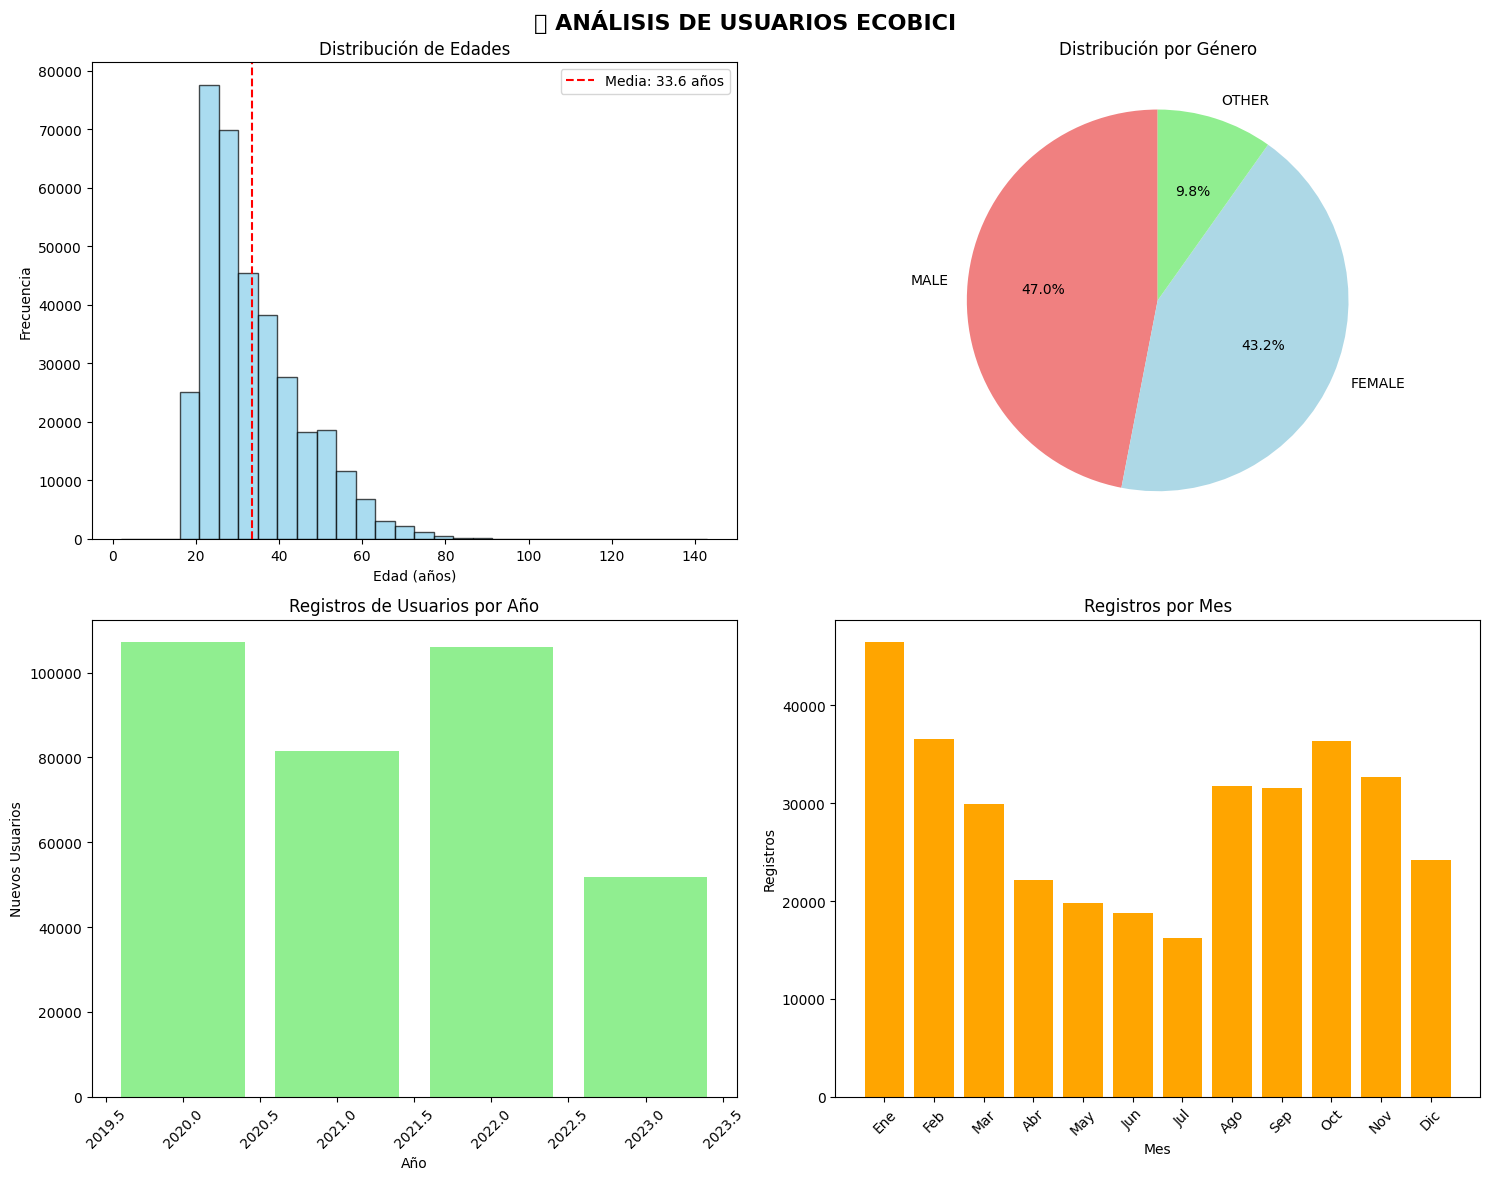

📈 Generando análisis temporal...


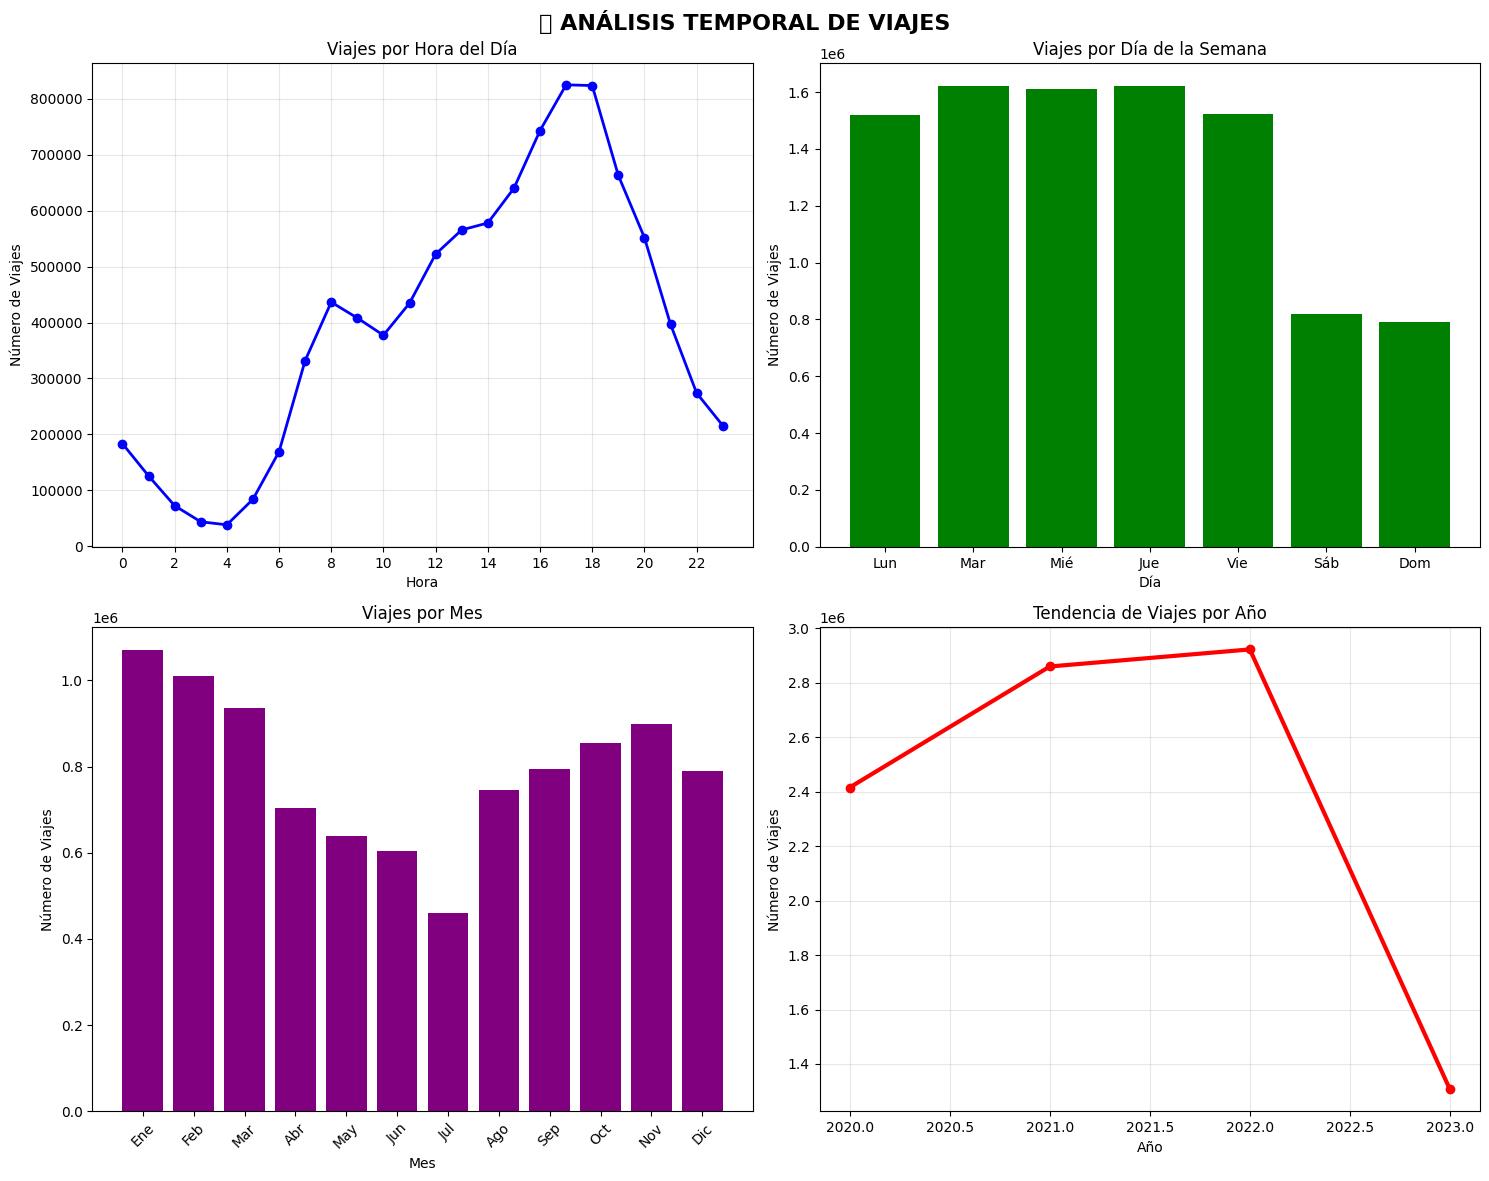

🚉 Generando análisis de estaciones...


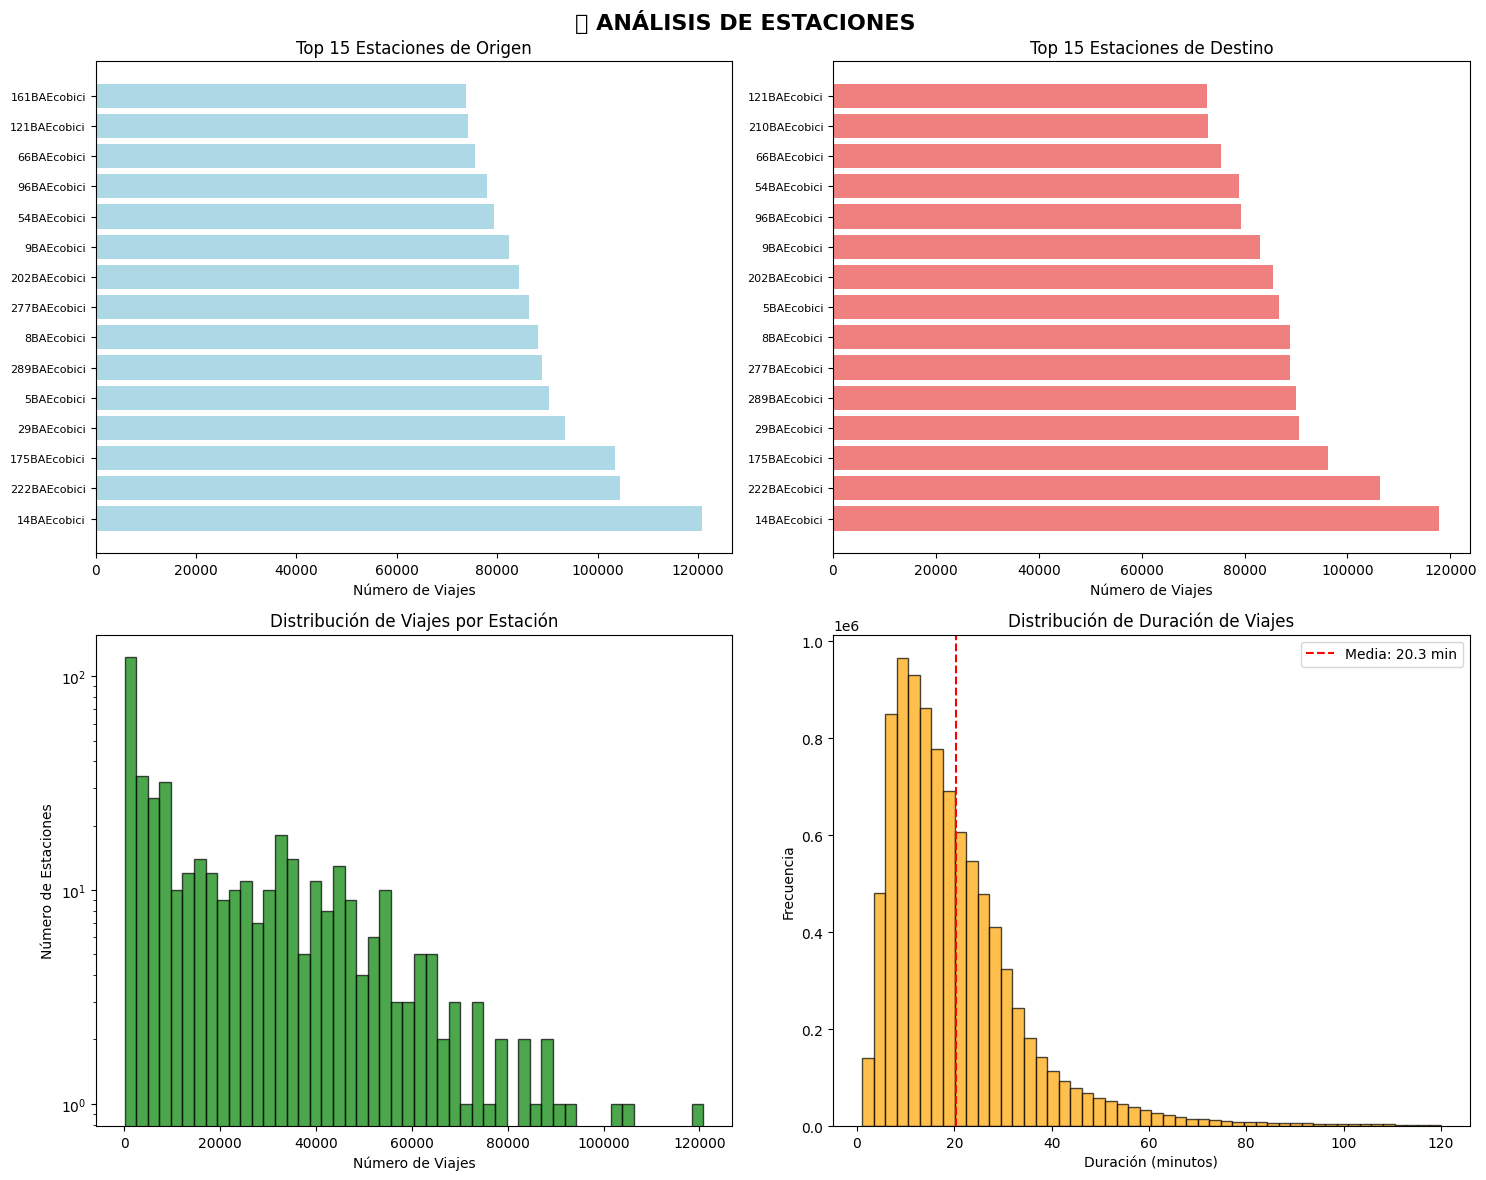

🔥 Generando heatmap de actividad...


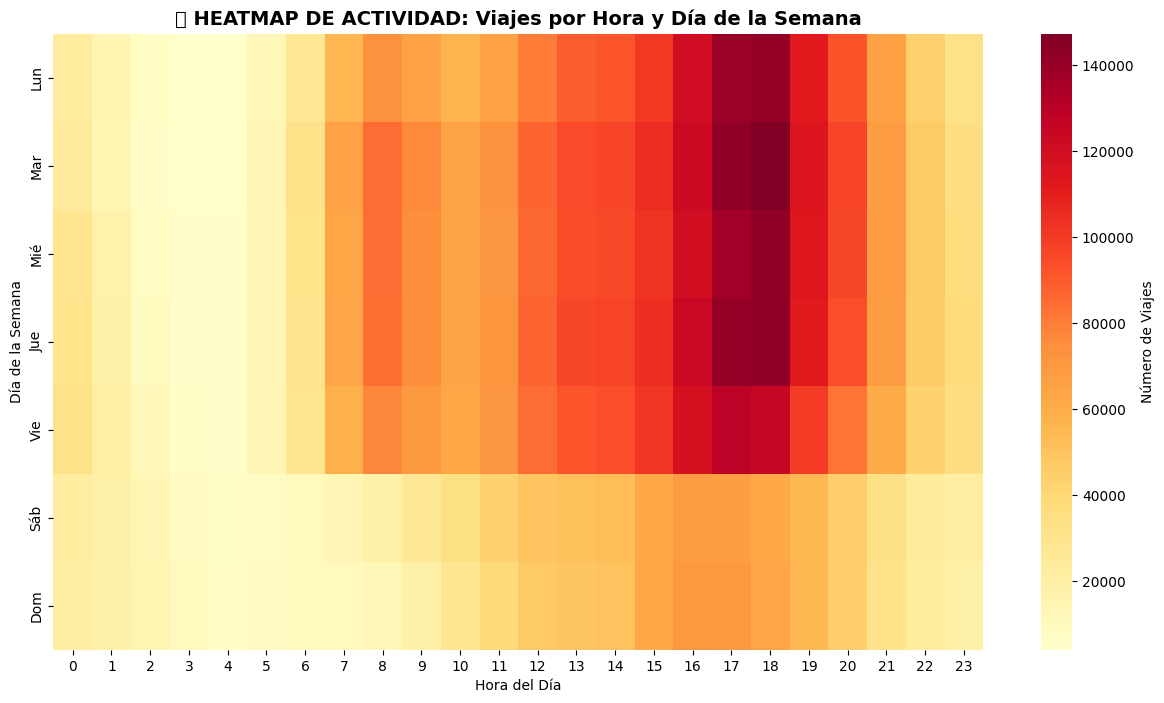


📊 ESTADÍSTICAS RESUMEN
👥 USUARIOS:
   • Total usuarios: 627,883
   • Edad promedio: 33.6 años
   • Distribución de género:
     - MALE: 162,712 (25.9%)
     - FEMALE: 149,785 (23.9%)
     - OTHER: 34,018 (5.4%)

🚲 VIAJES:
   • Total viajes: 14,380,108
   • Período: 2020-01-01 00:00:08 - 2023-06-29 23:59:55
   • Promedio viajes/día: 11,270
   • Estaciones únicas (origen): 447
   • Estaciones únicas (destino): 15
   • Duración promedio: 20.3 minutos

✅ Análisis gráfico completado!


In [16]:
# Preprocesar datos por separado (opcional)
processed_users = preprocess_users_data(users_train)
processed_trips = preprocess_trips_data(trips_train)

print(f"   • Usuarios en el set de entrenamiento: {users_train.shape}")
print(f"   • Viajes en el set de entrenamiento: {trips_train.shape}")

# Análisis gráfico completo
analyze_data_graphically(
    users_df=users_df,
    trips_df=trips_df,
    save_plots=False,
    processed_users=processed_users,
    processed_trips=processed_trips
)